# Ejercicio 2 — Cálculo de Itô y martingalas

**Máster Executive en Finanzas Cuantitativas 2026 · AFI Global Education**  
**Asignatura:** Fundamentos matemáticos — Procesos estocásticos

---

## Objetivo

1. determinar el drift que convierte el cociente $X_t/N_t$ en martingala;
2. resolver una integral de Itô mediante la dinámica de $W_t^3$;
3. demostrar que un cuadrado compensado es martingala, obtener su ley y verificarla por simulación.

Se distingue en todo momento entre una identidad analítica, una aproximación temporal de una integral de Itô y el error puramente Monte Carlo.


## Configuración del entorno


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2, kstest
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titleweight": "bold",
})

OUT = Path("resultados")
OUT.mkdir(exist_ok=True)
T = 1.0
print("Horizonte de las comprobaciones numéricas: T = 1 año")


Horizonte de las comprobaciones numéricas: T = 1 año


---

## Apartado 2.a — Drift para que $X_t/N_t$ sea martingala

Los procesos satisfacen:

$$dX_t=\mu X_tdt+\sigma X_tdW_t^{(1)},$$

$$dN_t=\frac12N_tdt+N_tdW_t^{(2)},$$

con $d\langle W^{(1)},W^{(2)}\rangle_t=\rho\,dt$. Definimos $Y_t=X_t/N_t$.

Primero, aplicando Itô a $f(n)=n^{-1}$:

$$d(N_t^{-1})=\frac12N_t^{-1}dt-N_t^{-1}dW_t^{(2)}.$$

La regla del producto incluye la covariación, que no puede omitirse:

$$dX_t\,d(N_t^{-1})=-\sigma\rho\,Y_tdt.$$

Por tanto,

$$dY_t
=Y_t\left[\left(\mu+\frac12-\sigma\rho\right)dt
\sigma dW_t^{(1)}-dW_t^{(2)}\right].$$

El drift se anula si y solo si:

$$\boxed{\mu=\sigma\rho-\frac12}.$$

Además, $\sigma W_t^{(1)}-W_t^{(2)}$ es un browniano escalado con tasa de varianza

$$q=\sigma^2+1-2\sigma\rho\geq0.$$

Bajo el valor anterior de $\mu$,

$$Y_t=Y_0\exp\left(-\frac12qt+\sigma W_t^{(1)}-W_t^{(2)}\right).$$

Es una exponencial estocástica de coeficientes constantes; no solo es una martingala local, sino una martingala verdadera en cualquier horizonte finito.


Ejemplo: sigma=0.30, rho=0.40
mu = sigma*rho - 1/2 = -0.3800
q = sigma² + 1 - 2*sigma*rho = 0.8500
Máximo desvío de E[Y_t]=Y_0 en unidades de SE: 2.09


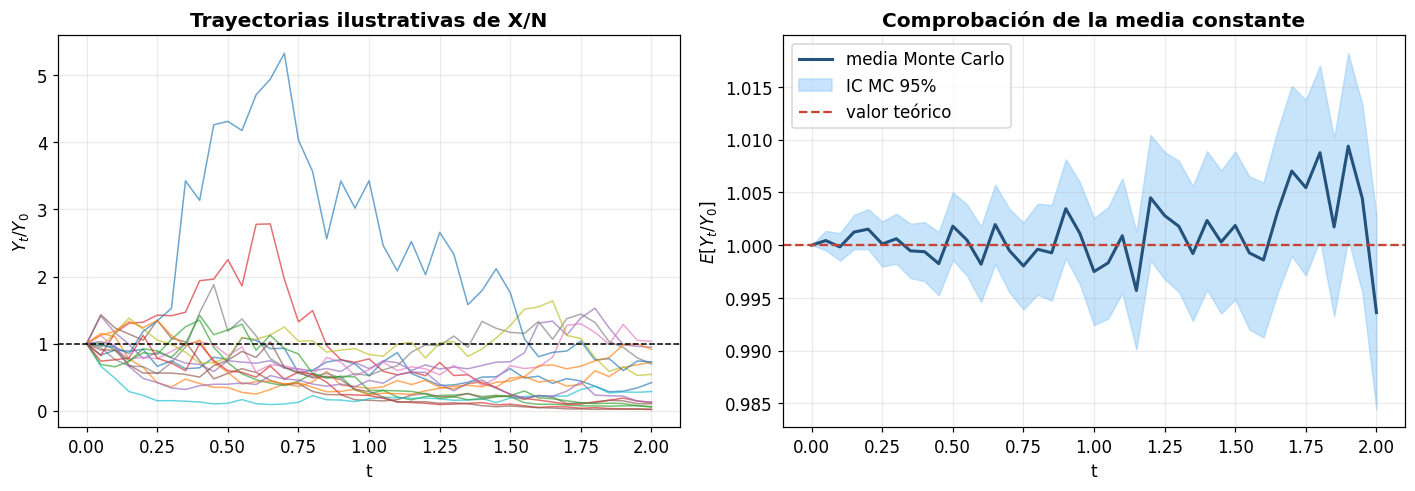

In [2]:
# Comprobación numérica ilustrativa; sigma y rho no están fijados en el enunciado.
sigma_demo = 0.30
rho_demo = 0.40
mu_demo = sigma_demo * rho_demo - 0.50
q_demo = sigma_demo**2 + 1.0 - 2.0 * sigma_demo * rho_demo
assert q_demo >= 0.0

t_grid = np.linspace(0.0, 2.0, 41)
n_mc = 200_000
rng = np.random.default_rng(20260201)
z = rng.standard_normal((n_mc, len(t_grid) - 1))
y_marginal = np.ones((n_mc, len(t_grid)))
y_marginal[:, 1:] = np.exp(
    -0.5 * q_demo * t_grid[1:]
    + np.sqrt(q_demo * t_grid[1:]) * z
)
media_mc = y_marginal.mean(axis=0)
se_mc = y_marginal.std(axis=0, ddof=1) / np.sqrt(n_mc)
z_media = np.divide(
    media_mc - 1.0, se_mc,
    out=np.zeros_like(media_mc), where=se_mc > 0,
)
assert np.max(np.abs(z_media)) < 5.5

# Trayectorias coherentes temporalmente del browniano efectivo.
n_paths_plot = 16
rng_paths = np.random.default_rng(20260202)
dt = t_grid[1] - t_grid[0]
B = np.c_[np.zeros(n_paths_plot),
          np.cumsum(np.sqrt(dt) * rng_paths.standard_normal(
              (n_paths_plot, len(t_grid) - 1)), axis=1)]
y_paths = np.exp(-0.5 * q_demo * t_grid + np.sqrt(q_demo) * B)

print(f"Ejemplo: sigma={sigma_demo:.2f}, rho={rho_demo:.2f}")
print(f"mu = sigma*rho - 1/2 = {mu_demo:.4f}")
print(f"q = sigma² + 1 - 2*sigma*rho = {q_demo:.4f}")
print(f"Máximo desvío de E[Y_t]=Y_0 en unidades de SE: "
      f"{np.max(np.abs(z_media)):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(t_grid, y_paths.T, alpha=0.65, lw=1)
axes[0].axhline(1.0, color="black", ls="--", lw=1)
axes[0].set(title="Trayectorias ilustrativas de X/N",
            xlabel="t", ylabel="$Y_t/Y_0$")

axes[1].plot(t_grid, media_mc, color="#24527a", lw=2, label="media Monte Carlo")
axes[1].fill_between(t_grid, media_mc - 1.96*se_mc, media_mc + 1.96*se_mc,
                     color="#90caf9", alpha=0.5, label="IC MC 95%")
axes[1].axhline(1.0, color="#c44536", ls="--", lw=1.5,
                label="valor teórico")
axes[1].set(title="Comprobación de la media constante",
            xlabel="t", ylabel="$E[Y_t/Y_0]$")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / "grafico_2a_cociente_martingala.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Apartado 2.b — Resolución de la integral

Se pide:

$$I_t=\int_0^t(W_s^2-s)\,dW_s.$$

Aplicamos Itô a $W_t^3$. Como $f'(x)=3x^2$ y $f''(x)=6x$:

$$d(W_t^3)=3W_t^2dW_t+3W_tdt.$$

Integrando:

$$\int_0^tW_s^2dW_s=\frac13W_t^3-\int_0^tW_sds.$$

Por integración por partes del producto determinista-estocástico $tW_t$:

$$d(tW_t)=W_tdt+t\,dW_t,$$

$$\int_0^ts\,dW_s=tW_t-\int_0^tW_sds.$$

Al restar, las integrales ordinarias se cancelan:

$$\boxed{I_t=\frac13W_t^3-tW_t}.$$

Como control adicional, $E[I_t]=0$ y, por isometría de Itô,

$$V(I_t)=\int_0^tE[(W_s^2-s)^2]ds
=\int_0^t2s^2ds=\frac23t^3.$$


In [3]:
def error_integral_ito(n_steps, n_paths=40_000, seed=0):
    '''Aproxima la integral con sumas de Itô por la izquierda.'''
    dt = T / n_steps
    rng = np.random.default_rng(seed)
    W = np.zeros(n_paths)
    I_riemann = np.zeros(n_paths)
    for j in range(n_steps):
        s = j * dt
        dW = np.sqrt(dt) * rng.standard_normal(n_paths)
        I_riemann += (W**2 - s) * dW
        W += dW
    I_cerrada = W**3 / 3.0 - T * W
    diferencia = I_riemann - I_cerrada
    return {
        "Pasos": n_steps,
        "dt": dt,
        "RMSE identidad": np.sqrt(np.mean(diferencia**2)),
        "Sesgo identidad": diferencia.mean(),
        "Media I cerrada": I_cerrada.mean(),
        "Varianza I cerrada": I_cerrada.var(ddof=1),
    }

tabla_conv = pd.DataFrame([
    error_integral_ito(50, seed=2050),
    error_integral_ito(200, seed=2200),
    error_integral_ito(800, seed=2800),
]).set_index("Pasos")

assert np.all(np.diff(tabla_conv["RMSE identidad"].values) < 0)
assert abs(tabla_conv.loc[800, "Varianza I cerrada"] - 2/3) < 0.03

display(tabla_conv.style.format({
    "dt": "{:.5f}", "RMSE identidad": "{:.6f}",
    "Sesgo identidad": "{:+.6f}", "Media I cerrada": "{:+.6f}",
    "Varianza I cerrada": "{:.6f}",
}))
print(f"Varianza teórica en t=1: {2/3:.6f}")


Varianza teórica en t=1: 0.666667


,dt,RMSE identidad,Sesgo identidad,Media I cerrada,Varianza I cerrada
Pasos,,,,,
50,0.02000,0.140808,+0.000344,-0.000841,0.650274
200,0.00500,0.070856,-0.000082,+0.002658,0.643326
800,0.00125,0.035489,-0.000333,+0.004753,0.651426


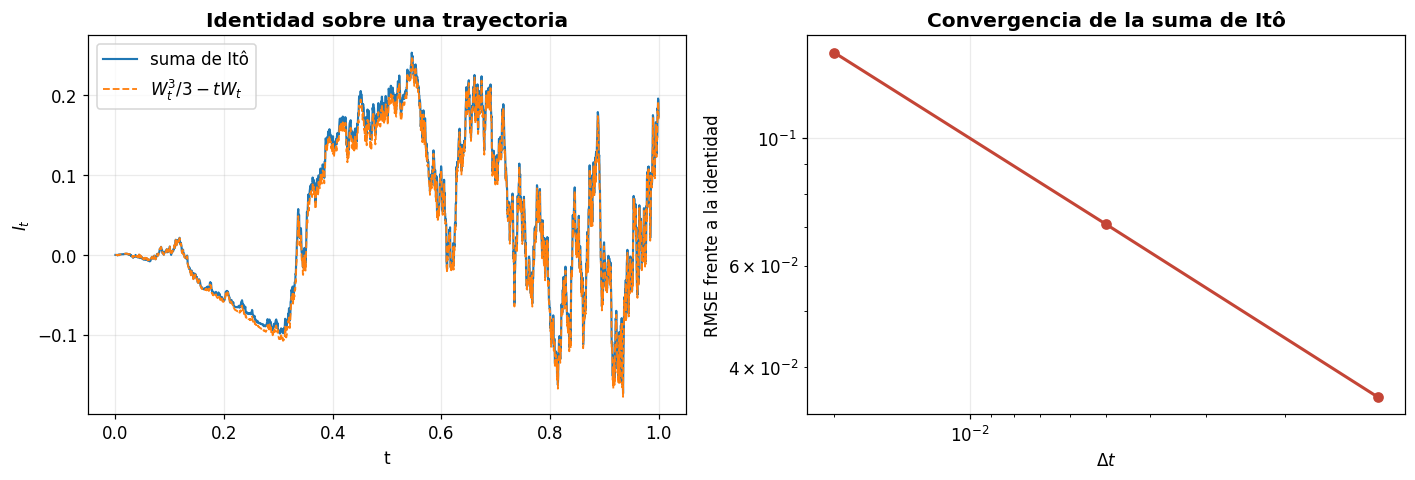

In [4]:
# Una trayectoria: suma de Itô frente a la expresión cerrada en todo el intervalo.
n_steps = 2_000
dt = T / n_steps
rng = np.random.default_rng(20260203)
W = 0.0
I_sum = 0.0
trayectoria_W = [0.0]
trayectoria_sum = [0.0]
trayectoria_cerrada = [0.0]
for j in range(n_steps):
    s = j * dt
    dW = np.sqrt(dt) * rng.standard_normal()
    I_sum += (W**2 - s) * dW
    W += dW
    t_now = (j + 1) * dt
    trayectoria_W.append(W)
    trayectoria_sum.append(I_sum)
    trayectoria_cerrada.append(W**3/3.0 - t_now*W)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tiempos = np.linspace(0, T, n_steps + 1)
axes[0].plot(tiempos, trayectoria_sum, lw=1.4, label="suma de Itô")
axes[0].plot(tiempos, trayectoria_cerrada, lw=1.2, ls="--",
             label="$W_t^3/3-tW_t$")
axes[0].set(title="Identidad sobre una trayectoria", xlabel="t", ylabel="$I_t$")
axes[0].legend()

axes[1].loglog(tabla_conv["dt"], tabla_conv["RMSE identidad"],
               marker="o", lw=2, color="#c44536")
axes[1].invert_xaxis()
axes[1].set(title="Convergencia de la suma de Itô",
            xlabel="$\\Delta t$", ylabel="RMSE frente a la identidad")
fig.tight_layout()
fig.savefig(OUT / "grafico_2b_integral_ito.png", dpi=150, bbox_inches="tight")
plt.show()


---

## Apartado 2.c.1 — Dos demostraciones de que $M_t$ es martingala

Definimos:

$$A_t=\int_0^ts\,dW_s,\qquad q_t=\langle A\rangle_t=\int_0^ts^2ds=\frac{t^3}{3},$$

$$M_t=A_t^2-q_t.$$

### Método 1: fórmula de Itô

Como $dA_t=t\,dW_t$ y $d\langle A\rangle_t=t^2dt$:

$$d(A_t^2)=2A_tdA_t+d\langle A\rangle_t
=2tA_tdW_t+t^2dt.$$

Puesto que $dq_t=t^2dt$:

$$\boxed{dM_t=2tA_t\,dW_t}.$$

No queda drift. Además,

$$E\left[\int_0^T4t^2A_t^2dt\right]
=4\int_0^Tt^2\frac{t^3}{3}dt<\infty,$$

así que la integral estocástica es cuadrado-integrable y $M_t$ es una martingala verdadera.

### Método 2: esperanza condicional e incrementos independientes

Para $0\leq s<t$, escribimos:

$$A_t=A_s+B_{s,t},\qquad B_{s,t}=\int_s^tu\,dW_u.$$

$B_{s,t}$ es independiente de $\mathcal F_s$, tiene media cero y varianza $q_t-q_s$. Entonces:

$$E[M_t\mid\mathcal F_s]
=A_s^2+E[B_{s,t}^2]-(q_t)
=A_s^2+(q_t-q_s)-q_t=M_s.$$

Para los cálculos posteriores elegimos el método de Itô, que da simultáneamente la dinámica y la integrabilidad.


## Apartado 2.c.2 — Distribución, esperanza y varianza

El integrando de $A_t$ es determinista. Por tanto:

$$A_t\sim N\left(0,q_t\right),\qquad q_t=\frac{t^3}{3}.$$

Si $Z\sim N(0,1)$, entonces $A_t=\sqrt{q_t}Z$ y:

$$\boxed{M_t=q_t(Z^2-1)=\frac{t^3}{3}(\chi_1^2-1)}.$$

Es una chi-cuadrado con un grado de libertad, desplazada y escalada; no es normal ni simétrica. Su soporte es $[-q_t,\infty)$.

$$\boxed{E[M_t]=0},\qquad
\boxed{V(M_t)=2q_t^2=\frac{2t^6}{9}}.$$

En $t=1$, $M_1=\frac13(\chi_1^2-1)$ y $V(M_1)=2/9$.


E[M1] teórica = 0; simulada = -0.000153 (SE=0.000665)
V[M1] teórica = 0.222222; simulada = 0.221344
KS tras deshacer escala/desplazamiento: D=0.0008, p=0.9292


,Teórico,Simulado
Probabilidad,,
0.010000,-0.333281,-0.333279
0.050000,-0.332023,-0.332027
0.500000,-0.181688,-0.181422
0.950000,+0.947153,+0.946370
0.990000,+1.878299,+1.878501


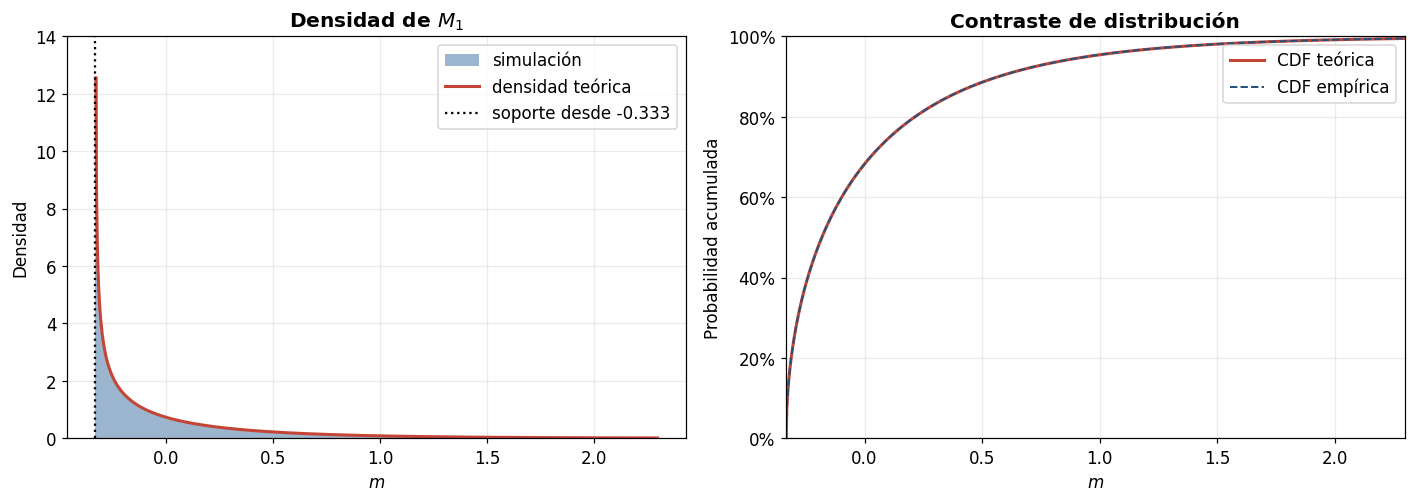

In [5]:
N_TERMINAL = 500_000
rng = np.random.default_rng(20260204)
q1 = T**3 / 3.0
Z = rng.standard_normal(N_TERMINAL)
M1 = q1 * (Z**2 - 1.0)

media_emp = M1.mean()
var_emp = M1.var(ddof=1)
se_media = M1.std(ddof=1) / np.sqrt(N_TERMINAL)
transformada_chi2 = M1 / q1 + 1.0
ks = kstest(transformada_chi2, "chi2", args=(1,))

niveles = np.array([0.01, 0.05, 0.50, 0.95, 0.99])
cuantiles = pd.DataFrame({
    "Teórico": q1 * (chi2.ppf(niveles, 1) - 1.0),
    "Simulado": np.quantile(M1, niveles),
}, index=niveles)
cuantiles.index.name = "Probabilidad"

assert abs(media_emp) < 4.0 * se_media
assert abs(var_emp - 2/9) / (2/9) < 0.015
assert M1.min() >= -q1 - 1e-14

print(f"E[M1] teórica = 0; simulada = {media_emp:+.6f} "
      f"(SE={se_media:.6f})")
print(f"V[M1] teórica = {2/9:.6f}; simulada = {var_emp:.6f}")
print(f"KS tras deshacer escala/desplazamiento: "
      f"D={ks.statistic:.4f}, p={ks.pvalue:.4f}")
display(cuantiles.style.format("{:+.6f}"))

m_max = np.quantile(M1, 0.995)
# La densidad diverge de forma integrable en -q. Se inicia la curva
# ligeramente a la derecha para no aplastar la región informativa.
m_grid = np.linspace(-q1 + 0.003, m_max, 800)
densidad = chi2.pdf(m_grid / q1 + 1.0, 1) / q1

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].hist(M1, bins=220, density=True, alpha=0.55, color="#4c78a8",
             range=(-q1, m_max), label="simulación")
axes[0].plot(m_grid, densidad, color="#c44536", lw=2,
             label="densidad teórica")
axes[0].axvline(-q1, color="black", ls=":", lw=1.5,
                label=f"soporte desde {-q1:.3f}")
axes[0].set(title="Densidad de $M_1$",
            xlabel="$m$", ylabel="Densidad", ylim=(0, 14))
axes[0].legend()

m_cdf = np.linspace(-q1, m_max, 1_000)
cdf_teorica = chi2.cdf(m_cdf/q1 + 1.0, 1)
ordenada = np.sort(M1)
idx = np.linspace(0, len(ordenada)-1, 2_000, dtype=int)
cdf_empirica = (idx + 1) / len(ordenada)
axes[1].plot(m_cdf, cdf_teorica, color="#c44536", lw=2,
             label="CDF teórica")
axes[1].plot(ordenada[idx], cdf_empirica, color="#24527a", lw=1.3,
             ls="--", label="CDF empírica")
axes[1].set(title="Contraste de distribución",
            xlabel="$m$", ylabel="Probabilidad acumulada",
            xlim=(-q1, m_max), ylim=(0, 1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / "grafico_2c_distribucion_M1.png", dpi=150, bbox_inches="tight")
plt.show()


## Apartado 2.c.3 — Simulación de trayectorias y contraste de martingala

En una malla $0=t_0<\cdots<t_n=1$ no es necesario introducir error de Euler. Los incrementos exactos son independientes y:

$$A_{t_j}-A_{t_{j-1}}
=\int_{t_{j-1}}^{t_j}s\,dW_s
\sim N\left(0,\frac{t_j^3-t_{j-1}^3}{3}\right).$$

Se simula ese incremento exacto, se acumula $A$ y se calcula $M=A^2-t^3/3$.

**Implementación directa en Excel** para una fila $j$:

| Columna | Contenido |
|---|---|
| A | tiempo $t_j$ |
| B | $q_j=t_j^3/3$ |
| C | $\Delta q_j=B_j-B_{j-1}$ |
| D | normal estándar: NORM.S.INV(RAND()) |
| E | $\Delta A_j=\sqrt{\Delta q_j}D_j$ |
| F | $A_j=F_{j-1}+E_j$ |
| G | $M_j=F_j^2-B_j$ |

Con una columna de normales por réplica se obtiene la distribución empírica en $t=1$.


In [6]:
n_steps = 100
n_ensemble = 100_000
n_show = 18
tiempos = np.linspace(0.0, 1.0, n_steps + 1)
q_grid = tiempos**3 / 3.0
dq = np.diff(q_grid)
rng = np.random.default_rng(20260205)

A = np.zeros(n_ensemble)
media_M = np.zeros(n_steps + 1)
se_M = np.zeros(n_steps + 1)
paths_M = np.zeros((n_show, n_steps + 1))
for j in range(1, n_steps + 1):
    A += np.sqrt(dq[j-1]) * rng.standard_normal(n_ensemble)
    M = A**2 - q_grid[j]
    media_M[j] = M.mean()
    se_M[j] = M.std(ddof=1) / np.sqrt(n_ensemble)
    paths_M[:, j] = M[:n_show]

# Contraste condicional entre s=0.5 y t=1.
N_COND = 400_000
s = 0.5
qs, qt = s**3/3.0, 1.0/3.0
rng_cond = np.random.default_rng(20260206)
A_s = np.sqrt(qs) * rng_cond.standard_normal(N_COND)
A_t = A_s + np.sqrt(qt-qs) * rng_cond.standard_normal(N_COND)
M_s = A_s**2 - qs
M_t = A_t**2 - qt
incremento = M_t - M_s

Xreg = np.column_stack([np.ones(N_COND), M_s])
intercepto, pendiente = np.linalg.lstsq(Xreg, M_t, rcond=None)[0]
grupos = pd.qcut(M_s, 5, labels=False)
tabla_cond = pd.DataFrame({
    "M_s": M_s, "Incremento": incremento, "Grupo": grupos
}).groupby("Grupo").agg(
    M_s_medio=("M_s", "mean"),
    incremento_medio=("Incremento", "mean"),
    n=("Incremento", "size"),
    sd=("Incremento", "std"),
)
tabla_cond["SE incremento"] = tabla_cond["sd"] / np.sqrt(tabla_cond["n"])
tabla_cond["z"] = tabla_cond["incremento_medio"] / tabla_cond["SE incremento"]

assert abs(intercepto) < 0.01
assert abs(pendiente - 1.0) < 0.03
assert np.max(np.abs(tabla_cond["z"])) < 4.0

print(f"Regresión empírica M_t = alfa + beta M_s: "
      f"alfa={intercepto:+.5f}, beta={pendiente:.5f}")
print("Incremento medio por quintil de M_s (debe ser 0):")
display(tabla_cond.style.format({
    "M_s_medio": "{:+.5f}", "incremento_medio": "{:+.5f}",
    "SE incremento": "{:.5f}", "z": "{:+.2f}", "sd": "{:.5f}",
}))


Regresión empírica M_t = alfa + beta M_s: alfa=-0.00056, beta=1.00149
Incremento medio por quintil de M_s (debe ser 0):


,M_s_medio,incremento_medio,n,sd,SE incremento,z
Grupo,,,,,,
0,-0.04078,+0.00088,80000,0.41434,0.00146,+0.60
1,-0.03522,+0.00092,80000,0.42806,0.00151,+0.61
2,-0.02227,-0.00304,80000,0.43133,0.00152,-1.99
3,+0.00447,-0.00240,80000,0.47158,0.00167,-1.44
4,+0.09354,+0.00086,80000,0.57542,0.00203,+0.42


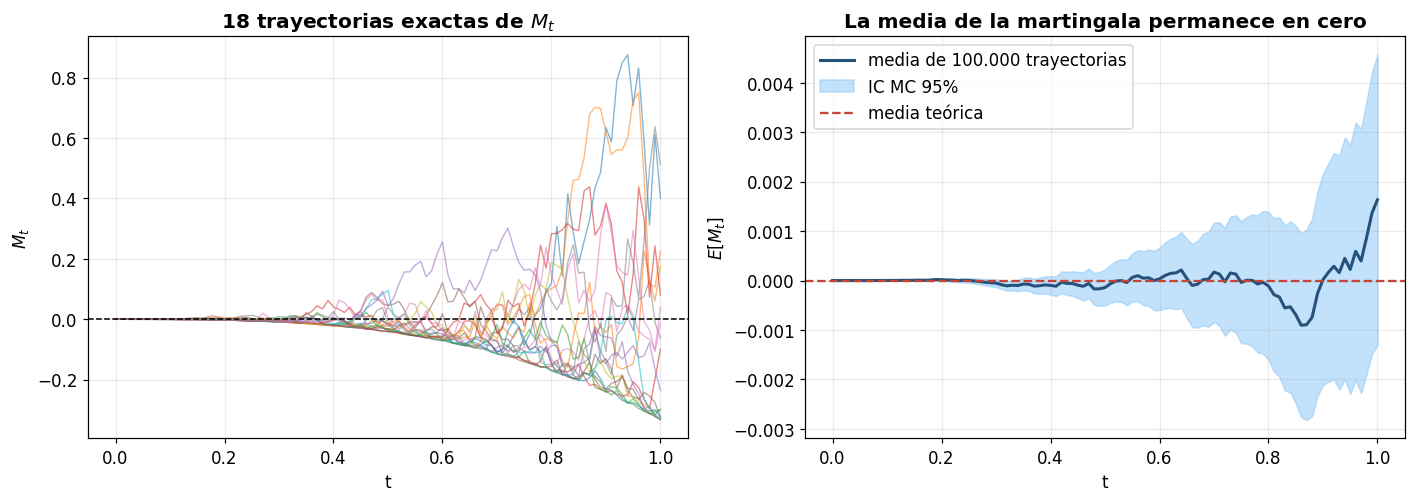

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].plot(tiempos, paths_M.T, alpha=0.55, lw=0.9)
axes[0].axhline(0.0, color="black", ls="--", lw=1)
axes[0].set(title="18 trayectorias exactas de $M_t$",
            xlabel="t", ylabel="$M_t$")

axes[1].plot(tiempos, media_M, color="#24527a", lw=2,
             label="media de 100.000 trayectorias")
axes[1].fill_between(tiempos, media_M-1.96*se_M, media_M+1.96*se_M,
                     color="#90caf9", alpha=0.55, label="IC MC 95%")
axes[1].axhline(0.0, color="#c44536", ls="--", lw=1.5,
                label="media teórica")
axes[1].set(title="La media de la martingala permanece en cero",
            xlabel="t", ylabel="$E[M_t]$")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT / "grafico_2c_trayectorias_martingala.png",
            dpi=150, bbox_inches="tight")
plt.show()


---

## Conclusiones

- En el cociente $X/N$, la corrección de drift contiene la covariación entre brownianos: $\mu=\sigma\rho-1/2$.
- La integral del apartado 2.b se reduce exactamente al tercer polinomio de Hermite escalado, $W_t^3/3-tW_t$.
- $M_t$ es el cuadrado compensado de una martingala gaussiana. Su ley es una $\chi_1^2$ desplazada y escalada, con media cero y varianza $2t^6/9$.
- Las simulaciones contrastan por separado la identidad de Itô, la distribución terminal y la propiedad condicional de martingala.


In [8]:
print("=" * 76)
print("RESUMEN EJERCICIO 2")
print("=" * 76)
print("2.a  mu = sigma*rho - 1/2")
print("2.b  I_t = W_t^3/3 - t W_t;  Var(I_t) = 2 t^3/3")
print(f"2.c  t=1: E[M_1]=0, Var(M_1)=2/9={2/9:.6f}")
print(f"     Simulación: media={media_emp:+.6f}, varianza={var_emp:.6f}")
print(f"     Contraste condicional: alfa={intercepto:+.5f}, beta={pendiente:.5f}")


RESUMEN EJERCICIO 2
2.a  mu = sigma*rho - 1/2
2.b  I_t = W_t^3/3 - t W_t;  Var(I_t) = 2 t^3/3
2.c  t=1: E[M_1]=0, Var(M_1)=2/9=0.222222
     Simulación: media=-0.000153, varianza=0.221344
     Contraste condicional: alfa=-0.00056, beta=1.00149
